En este ejemplo se utilizará el conjunto de datos Pima Indians Diabetes, ampliamente utilizado para clasificación binaria en salud. El objetivo es predecir si una paciente presenta diabetes (Outcome) a partir de variables clínicas.

La variable respuesta será:

Outcome = 1: diabetes.
Outcome = 0: no diabetes.

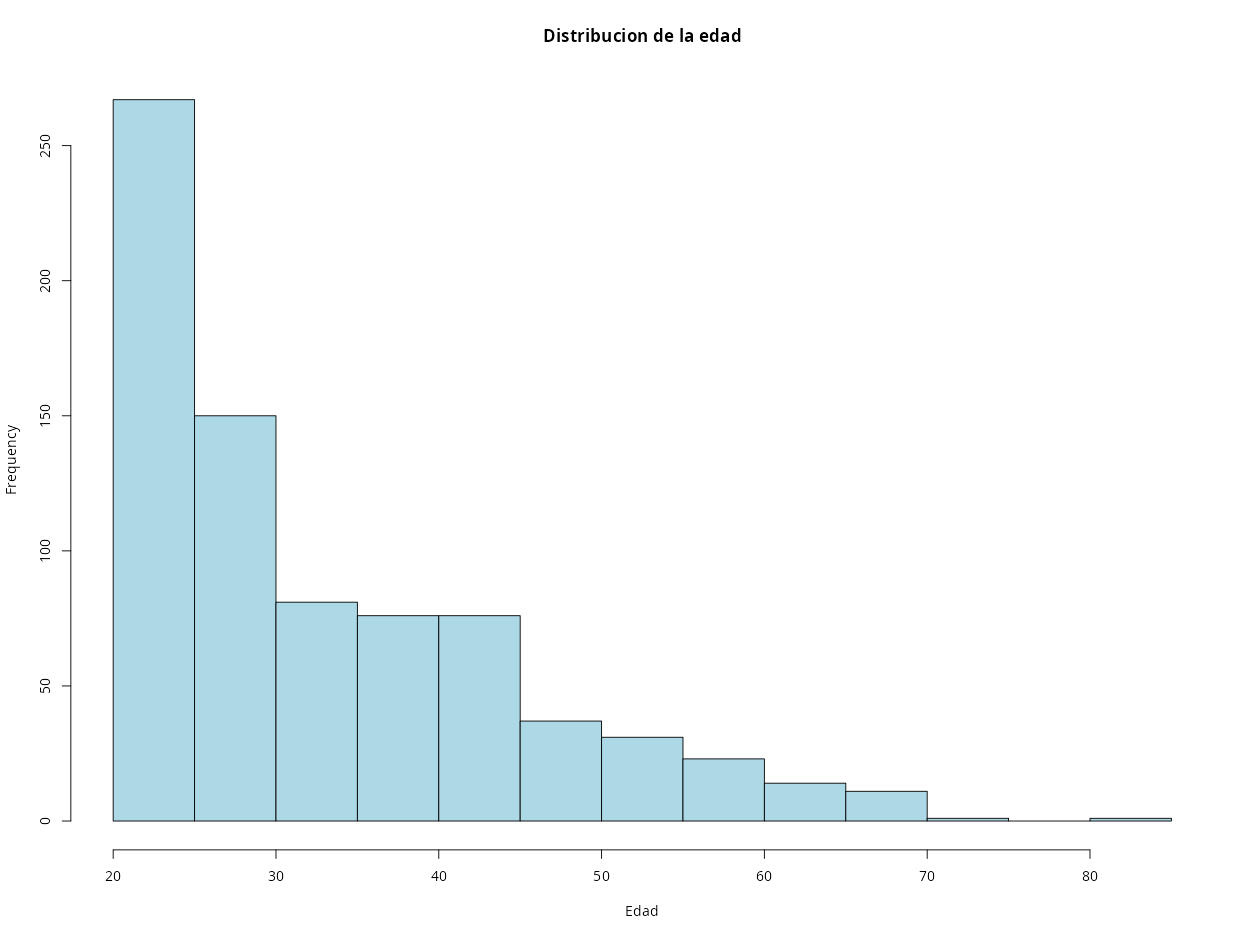

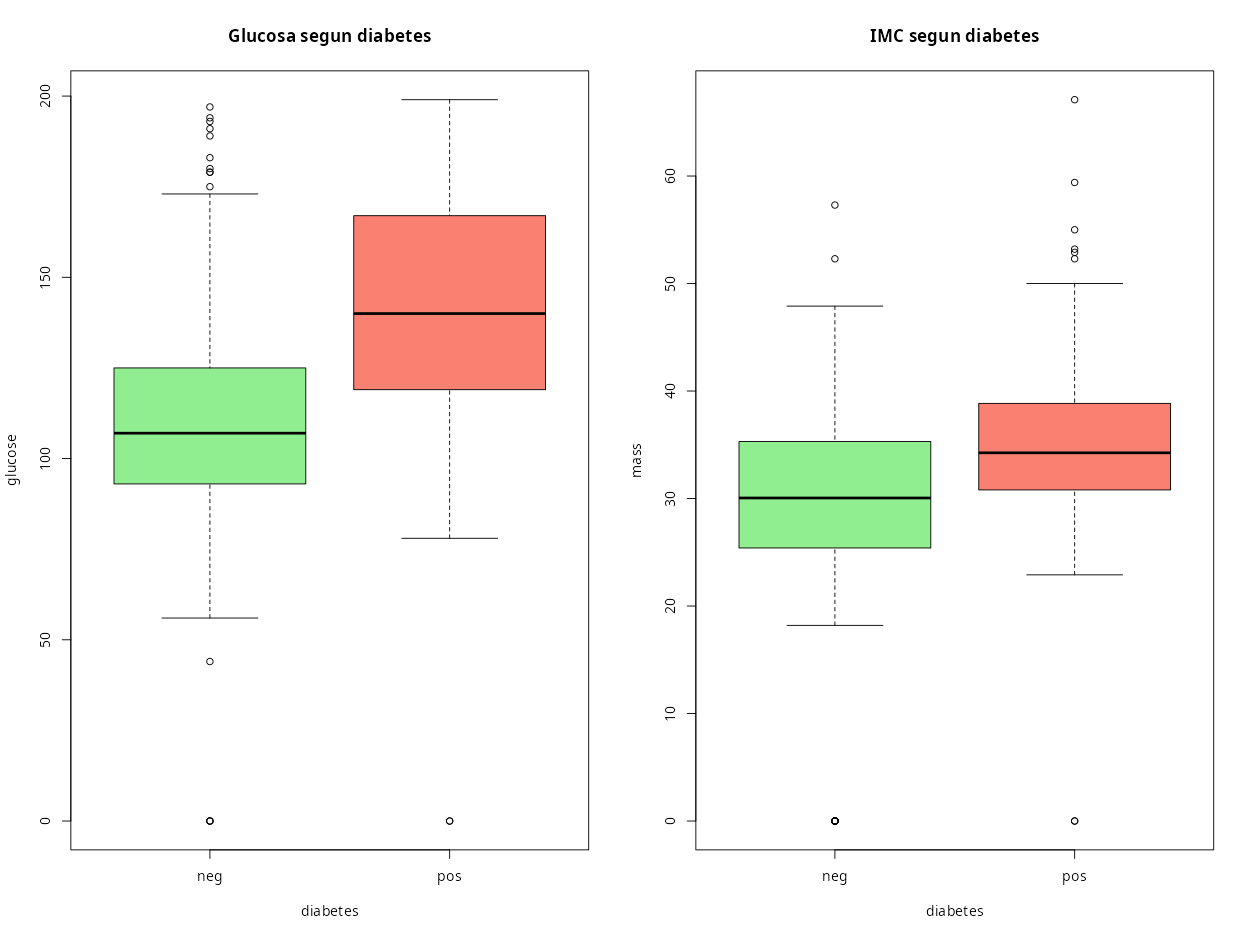

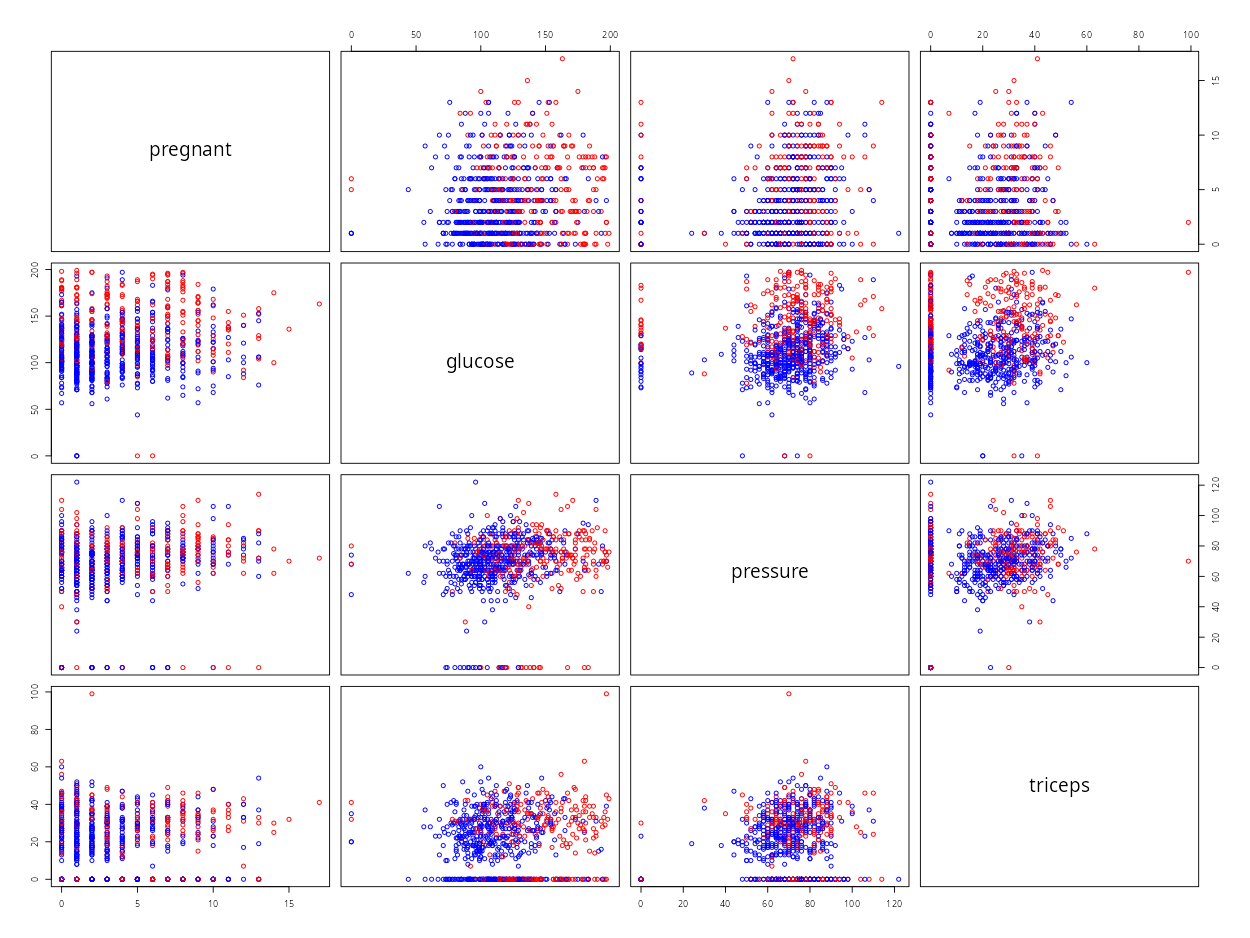

Setting levels: control = neg, case = pos
Setting direction: controls < cases


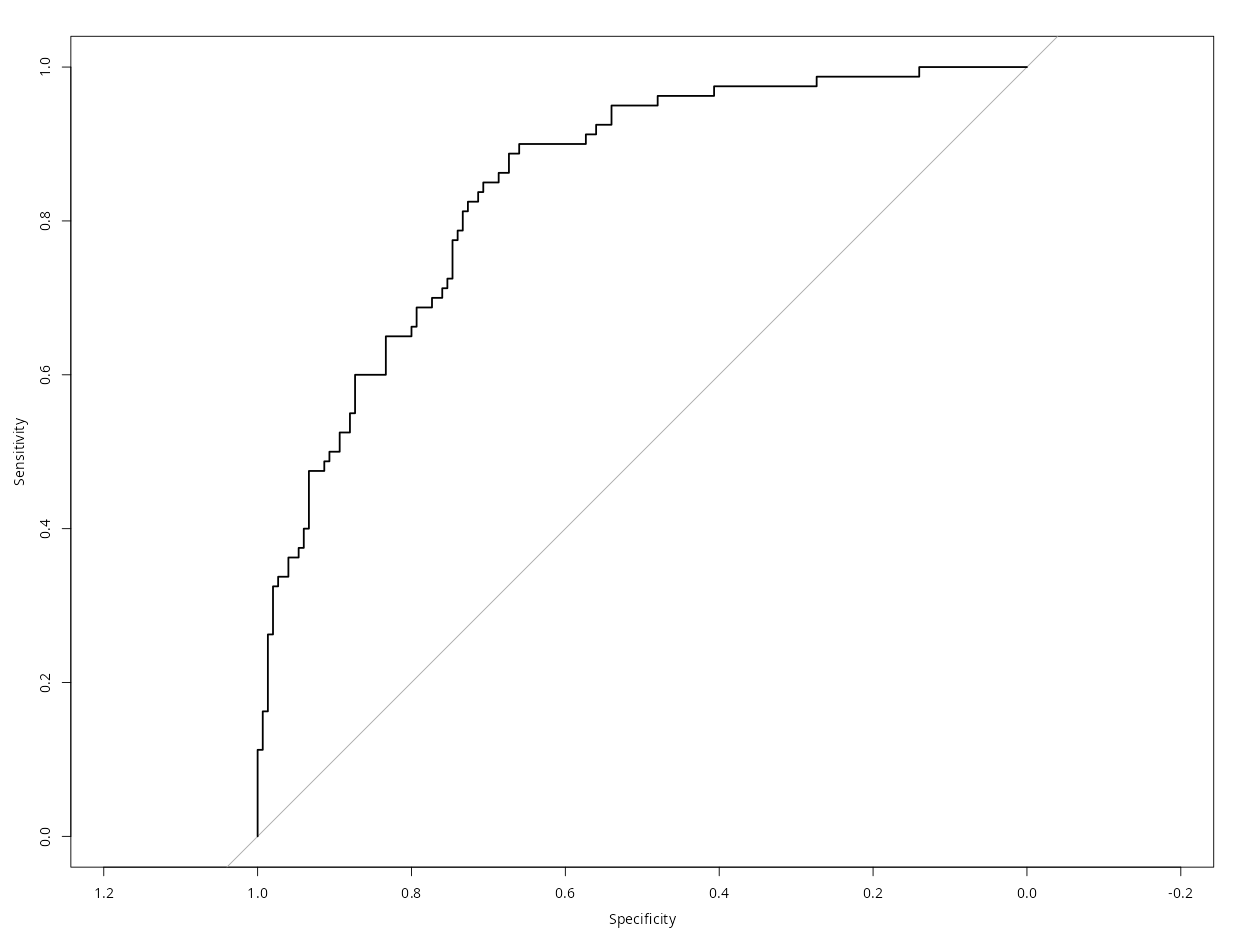

Area under the curve: 0.8438

In [5]:
library(mlbench)
library(caret)
library(pROC)
library(ResourceSelection)
library(car)

data(PimaIndiansDiabetes)

datos <- PimaIndiansDiabetes
datos$diabetes <- factor(datos$diabetes)

set.seed(123)

indice <- createDataPartition(
    datos$diabetes,
    p = 0.7,
    list = FALSE
)

# eda
# distribucion de la edad
hist(datos$age,
     col = "lightblue",
     main = "Distribucion de la edad",
     xlab = "Edad")

# confiura un par completo de graficos para los boxplot
par(mfrow=c(1,2))
# glucosa segun diabetes
boxplot(glucose ~ diabetes,
        data = datos,
        col = c("lightgreen","salmon"),
        main = "Glucosa segun diabetes")

# indice de masa corporal segun diabetes
boxplot(mass ~ diabetes,
        data = datos,
        col = c("lightgreen","salmon"),
        main = "IMC segun diabetes")

par(mfrow=c(1,1))

# matriz de correlacion
cor(datos[,1:8])
pairs(datos[,1:4],
      col = ifelse(datos$diabetes=="pos",
                   "red","blue"))

# División entrenamiento y prueba

set.seed(123)

indice <- createDataPartition(datos$diabetes,
                              p = 0.7,
                              list = FALSE)
train <- datos[indice,]
test <- datos[-indice,]

# ajuste del modelo de regresión logística
modelo <- glm(
    diabetes ~ glucose + mass +
                age + pregnant +
                pressure,
    data = train,
    family = binomial
)

summary(modelo)

exp(coef(modelo))

AIC(modelo)

vif(modelo)

prob_train <- predict(modelo,
                      type="response")

hoslem.test(
    as.numeric(train$diabetes)-1,
    prob_train
)

prob_test <- predict(
    modelo,
    newdata=test,
    type="response"
)

pred <- ifelse(prob_test > 0.5,
               "pos",
               "neg")

pred <- factor(pred,
               levels=c("neg","pos"))

confusionMatrix(pred,
                test$diabetes)

roc_obj <- roc(test$diabetes,
               prob_test)

plot(roc_obj)

auc(roc_obj)

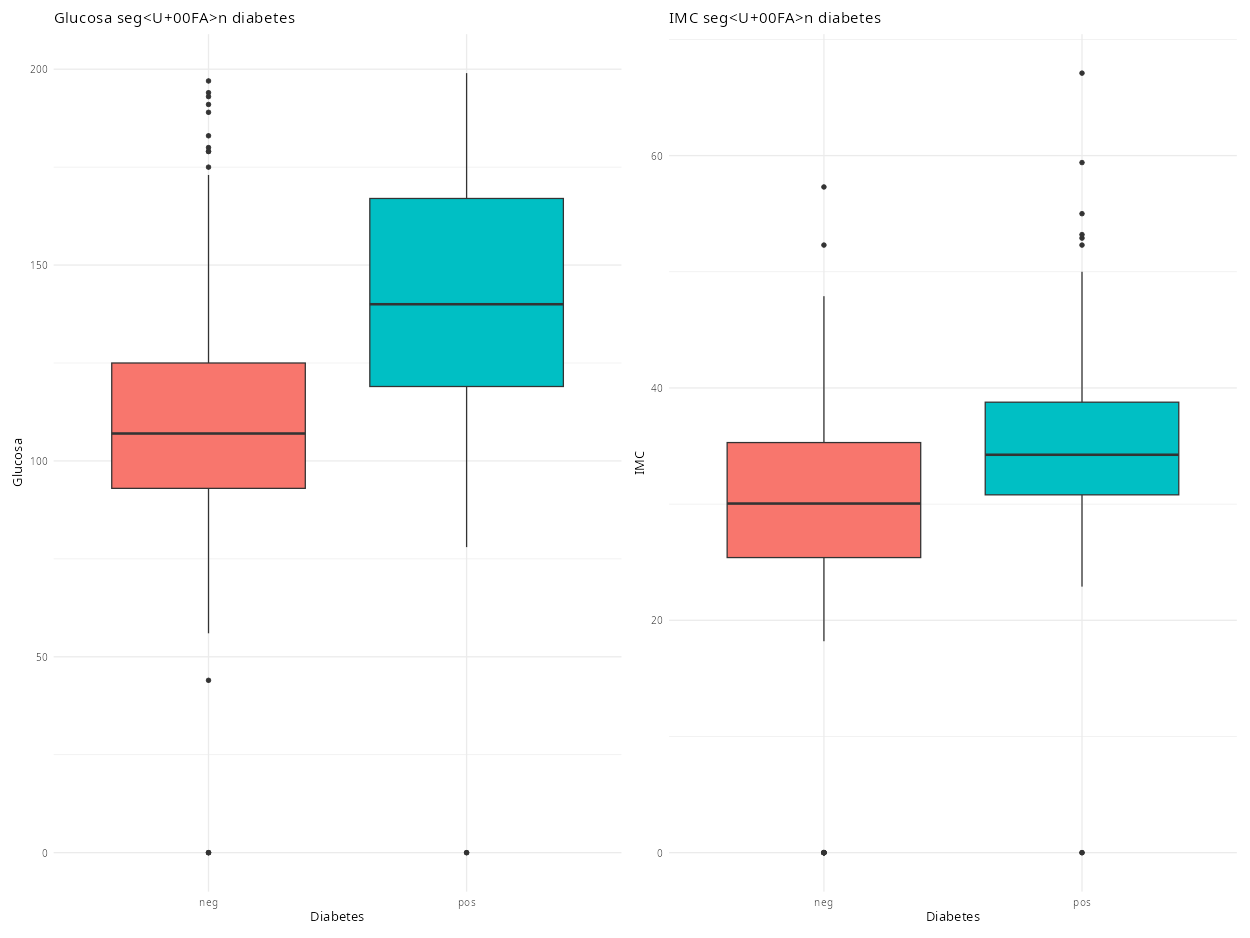

In [ ]:
# Visualización de resultados con ggplot2 y patchwork
library(ggplot2)
library(patchwork)

g1 <- ggplot(datos,
             aes(x = diabetes,
                 y = glucose,
                 fill = diabetes)) +
  geom_boxplot() +
  labs(title = "Glucosa según diabetes",
       x = "Diabetes",
       y = "Glucosa") +
  theme_minimal() +
  theme(legend.position = "none")

g2 <- ggplot(datos,
             aes(x = diabetes,
                 y = mass,
                 fill = diabetes)) +
  geom_boxplot() +
  labs(title = "IMC según diabetes",
       x = "Diabetes",
       y = "IMC") +
  theme_minimal() +
  theme(legend.position = "none")

g1 + g2